**Menginstal libary yang dibutuhkan**

In [131]:
!pip install google-play-scraper
!pip install Sastrawi
!pip install nltk
!pip install gensim
!pip install scikit-learn
!pip install pandas numpy matplotlib

**Import semua libary yang dibutuhkan**

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import string
import seaborn as sns
import datetime as dt
from nltk.tokenize import word_tokenize

# libary NLP bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# libary Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
from gensim.models import Word2Vec

**Load Dataset**

In [133]:
df = pd.read_csv('ulasan_aplikasi_shopee.csv')

In [134]:
print(f"total data: {len(df)}")
print(f"kolom: {df.columns.tolist()}")
print(f"tabel data:")
df.head() # menampilkan 5 data teratas

total data: 12000
kolom: ['userName', 'content', 'score', 'at']
tabel data:


,userName,content,score,at
0,Pengguna Google,untuk update nya selanjutnya mohon investasi e...,4,2026-03-06 13:08:53
1,Pengguna Google,aplikasi Nya Bagus,5,2026-03-06 13:08:07
2,Pengguna Google,terimakasih,5,2026-03-06 13:07:21
3,Pengguna Google,mempermudah untuk berbelanja apa saja.pilihan ...,5,2026-03-06 13:06:05
4,Pengguna Google,Gila ngeselin banget sering nge leq padahal ud...,1,2026-03-06 13:05:14


In [135]:
df.info() # menampilkan info dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  12000 non-null  object
 1   content   12000 non-null  object
 2   score     12000 non-null  int64 
 3   at        12000 non-null  object
dtypes: int64(1), object(3)
memory usage: 375.1+ KB


**Data preparation**

In [136]:
clean_df = df.dropna(subset=['content']) # menghapus data yang kosong
clean_df = clean_df.drop_duplicates() # menghapus data yang duplikat
clean_df = clean_df.reset_index(drop=True) # mereset index setelah data dihapus

In [137]:
print(f"Total data setelah cleaning: {len(clean_df)}")
clean_df.info()

Total data setelah cleaning: 12000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  12000 non-null  object
 1   content   12000 non-null  object
 2   score     12000 non-null  int64 
 3   at        12000 non-null  object
dtypes: int64(1), object(3)
memory usage: 375.1+ KB


**Inisialisasi Sastrawi**

In [138]:
# stemmer mengubah kata berimbuhan menjadi kata dasar
# stopword menghapus kata yang tidak terlalu penting
# download resource nltk yang dibutuhkan

import nltk
nltk.download('stopwords')   # untuk filteringText
nltk.download('punkt')       # untuk tokenizingText (word_tokenize)
nltk.download('punkt_tab')   # untuk tokenizingText versi yang terbaru

factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()
factory_stopword = StopWordRemoverFactory()
stopword = factory_stopword.create_stop_word_remover()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**Preprocessing text**

In [139]:
def cleaningText(text):
    text = re.sub(r'RT[\s]', '', text)                                 # menghapus RT
    text = re.sub(r"http\S+", '', text)                                # menghapus link
    text = re.sub(r'[0-9]+', '', text)                                 # menghapus angka
    text = re.sub(r'#[A-Za-z0-9]+', '', text)                          # menghapus hashtag
    text = re.sub(r'@[A-Za-z0-9]+', '', text)                          # menghapus mention
    text = re.sub(r'[^\w\s]', '', text)                                # menghapus karakter selain huruf dan angka
    text = text.replace('\n', ' ')                                     # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation))   # menghapus semua tanda baca
    text = text.strip(' ')                                             # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(nltk.corpus.stopwords.words('indonesian'))
    listStopwords1 = set(nltk.corpus.stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',
                          'di','ga','ya','gaa','loh','kah','woi',
                          'woii','woy'])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]  # menggunakan stemmer dari cell Inisialisasi Sastrawi
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [140]:
# mendefinisikan kembali fungsi slangword yang sebenarnya
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "leq": "lag", "didonlot": "didonwload",
              "lelet": "lambat", "tp": "tapi", "yg": "yang", "ngeleg": "ngelag", "spyletter": "SPayLater", "blm": "belum", "apk": "aplikasi","skarang": "sekarang", "qrish": "QRIS",
              "g": "gak", "ny": "nya", "pnya": "punya", "uda": "sudah", "tdk": "tidak", "elu": "kamu", "layan": "layanan", "sya": "saya", "mmbaik": "membaik"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [141]:
# menerapkan semua fungsi preprocessing ke dataframe
# membutuhkan waktu sekitar ~20menit karena menggunakan 12000 data

# cleaning - menghapus karakter tidak penting
clean_df['content'] = clean_df['content'].apply(cleaningText)

# casefolding - mengubah semua huruf jadi kecil
clean_df['content'] = clean_df['content'].apply(casefoldingText)

# fix slangword - mengubah kata tidak baku jadi baku
clean_df['content'] = clean_df['content'].apply(fix_slangwords)

# tokenizing - pecah kalimat menjadi list kata
clean_df['text_token'] = clean_df['content'].apply(tokenizingText)

# filtering - menghapus stopword
clean_df['text_stopword'] = clean_df['text_token'].apply(filteringText)

# stemming - mengubah kata ke bentuk dasar
clean_df['text_stemmed'] = clean_df['text_stopword'].apply(lambda x: stemmingText(' '.join(x)))

# menggunakan hasil stemming
clean_df['clean_text'] = clean_df['text_stemmed']

# hapus baris yang clean_text nya kosong setelah preprocessing
clean_df = clean_df[clean_df['clean_text'].str.strip() != ''].reset_index(drop=True)

print("Preprocessing selesai!")
print(f"Total data: {len(clean_df)}")
clean_df[['content', 'clean_text']].head()

Preprocessing selesai!
Total data: 11648


,content,clean_text
0,untuk update nya selanjutnya mohon investasi e...,update mohon investasi emas jual mohon shopeep...
1,aplikasi nya bagus,aplikasi bagus
2,terimakasih,terimakasih
3,mempermudah untuk berbelanja apa sajapilihan m...,mudah belanja sajapilihan metode bayar agam
4,gila ngeselin banget sering nge lag padahal ud...,gila ngeselin banget nge lag udah update make ...


**Load lexicon sentimen bahasa Indonesia**

In [142]:
# berisi daftar kata positif dan negatif beserta nilainya
# referensi kamus lexicon yang digunakan

url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

# ngeload kamus positif dan negatif
# header=0 = baris pertama dijadikan header otomatis

pos_df = pd.read_csv(url_pos, sep='\t', header=0)
neg_df = pd.read_csv(url_neg, sep='\t', header=0)

print(pos_df.head())
print(pos_df.columns.tolist())

        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2
['word', 'weight']


In [143]:
# mengubah bentuk dictionary
positive_lexicon = dict(zip(pos_df['word'], pos_df['weight'].astype(float)))
negative_lexicon = dict(zip(neg_df['word'], neg_df['weight'].astype(float)))
print(f"Jumlah kata positif: {len(positive_lexicon)}")
print(f"Jumlah kata negatif: {len(negative_lexicon)}")

Jumlah kata positif: 3609
Jumlah kata negatif: 6607


In [144]:
# menambahkan dan mengoreksi kata yang bernilai salah di Inset

positive_lexicon['bagus']   = 3.0
positive_lexicon['baik']    = 2.0
positive_lexicon['baguss']  = 3.0
positive_lexicon['keren']   = 3.0
positive_lexicon['mantap']  = 3.0
positive_lexicon['mudah']   = 2.0
positive_lexicon['senang']  = 2.0
positive_lexicon['suka']    = 2.0
positive_lexicon['hebat']   = 3.0
positive_lexicon['canggih'] = 2.0
positive_lexicon['aplikasi'] = 3.0
positive_lexicon['membaik'] = 3.0

negative_lexicon['stuck']   = -2.0
negative_lexicon['error']   = -3.0
negative_lexicon['lemot']   = -2.0
negative_lexicon['lambat']  = -2.0
negative_lexicon['rusak']   = -3.0
negative_lexicon['kecewa']  = -3.0
negative_lexicon['buruk']   = -3.0
negative_lexicon['jelek']   = -3.0
negative_lexicon['susah']   = -2.0
negative_lexicon['masalah'] = -2.0

# menghapus kata 'aplikasi' dari referensi kamus negatif jika ada untuk keperluan nilai polarity dari (clean_text) dari distribusi label
if 'aplikasi' in negative_lexicon:
    del negative_lexicon['aplikasi']

print("koreksi lexicon selesai")

koreksi lexicon selesai


**Pelabelan data**

In [145]:
# input = clean_text yang sudah di preprocessing
# output = polarity_score (angka) + polarity (label)
def sentiment_analysis_lexicon_indonesia(text):
    tokens = text.split()

    # menghitung total skor dari setiap kata
    score = 0
    for word in tokens:
        if word in positive_lexicon:
            score += positive_lexicon[word]
        if word in negative_lexicon:
            score += negative_lexicon[word]

    # menentukan label berdasarkan total skor
    if score > 0:
        polarity = 'positif'
    elif score < 0:
        polarity = 'negatif'
    else:
        polarity = 'netral'

    return score, polarity

In [146]:
results = clean_df['clean_text'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity']       = results[1]
print("\ndistribusi label:")
print(clean_df['polarity'].value_counts())
clean_df[['content', 'clean_text', 'polarity_score', 'polarity']].head(20)

# ada yang tidak wajar dari clean_text ke hasil polarity nya (ambigu)
# mungkin karena keterbatasan dari referensi kamus lexicon yang saya gunakan


distribusi label:
polarity
positif    6262
negatif    3774
netral     1612
Name: count, dtype: int64


,content,clean_text,polarity_score,polarity
0,untuk update nya selanjutnya mohon investasi e...,update mohon investasi emas jual mohon shopeep...,15.0,positif
1,aplikasi nya bagus,aplikasi bagus,2.0,positif
2,terimakasih,terimakasih,5.0,positif
3,mempermudah untuk berbelanja apa sajapilihan m...,mudah belanja sajapilihan metode bayar agam,-2.0,negatif
4,gila ngeselin banget sering nge lag padahal ud...,gila ngeselin banget nge lag udah update make ...,-15.0,negatif
5,masih di bintang soalnya SPayLater masih belum...,bintang spaylater,0.0,netral
6,paket saya stuck di bekasi virtual dc dan sema...,paket stuck bekas virtual dc semarang dc woiii...,4.0,positif
7,tidak dapat didonwload terus gimana caranya bi...,didonwload gimana belanja shopee mohon batu,-1.0,negatif
8,bug shopee live video sering terjadisemoga bis...,bug shopee live video terjadisemoga atas,-1.0,negatif
9,sangat bagus aplikasinya,bagus aplikasi,2.0,positif


**Visualisasi distribusi label sentimen & polarity**

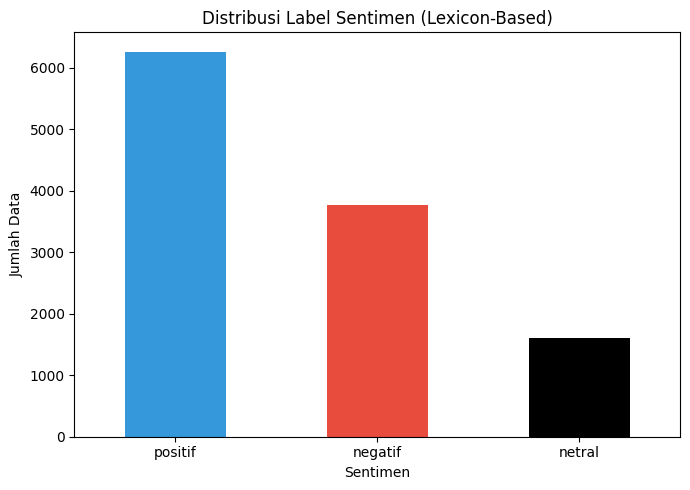

In [147]:
import matplotlib.pyplot as plt

colors = ['#3498DB', '#e74c3c', '#000000']
clean_df['polarity'].value_counts().plot(
    kind='bar',
    color=colors,
    title='Distribusi Label Sentimen (Lexicon-Based)',
    figsize=(7, 5)
)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

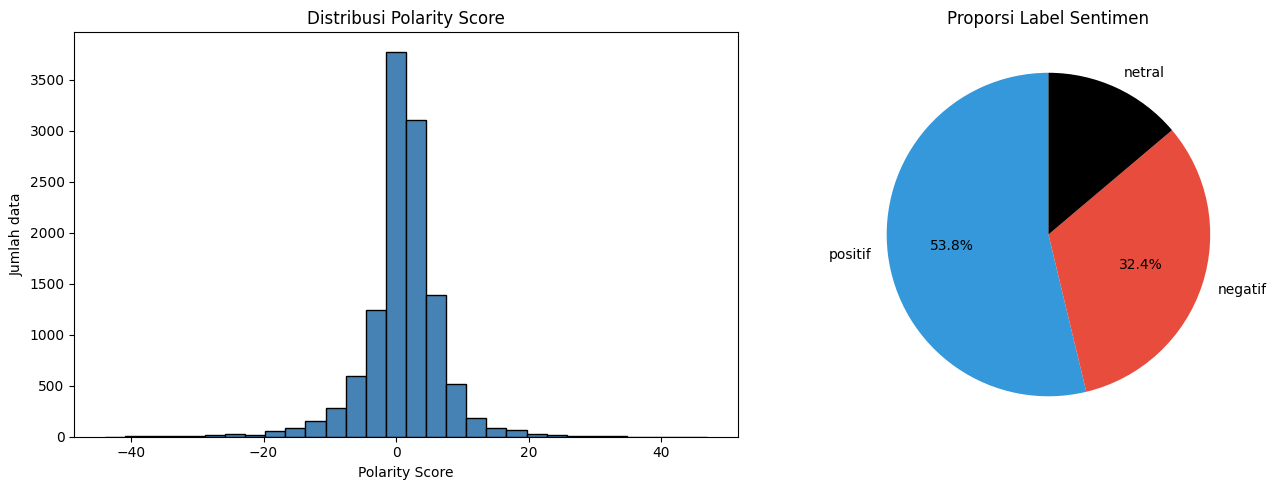

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram polarity score
axes[0].hist(clean_df['polarity_score'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Polarity Score')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Jumlah data')

# pie chart distribusi label
label_counts = clean_df['polarity'].value_counts()
axes[1].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=['#3498DB', '#e74c3c', '#000000'],
    startangle=90)
axes[1].set_title('Proporsi Label Sentimen')

plt.tight_layout()
plt.show()

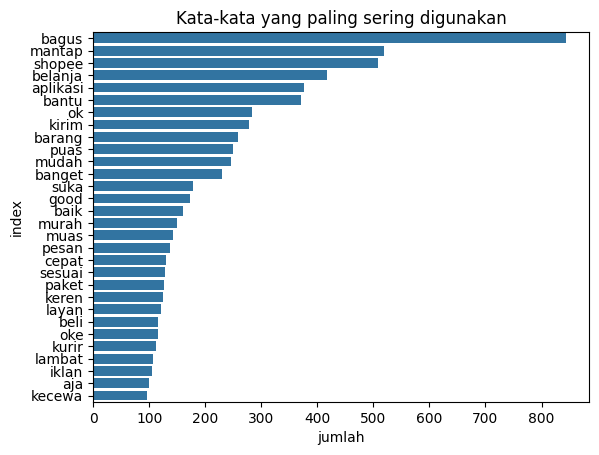

In [149]:
# kata yang paling banyak keluar atau muncul
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['clean_text'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(30)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Kata-kata yang paling sering digunakan')
plt.show()

**Word cloud**

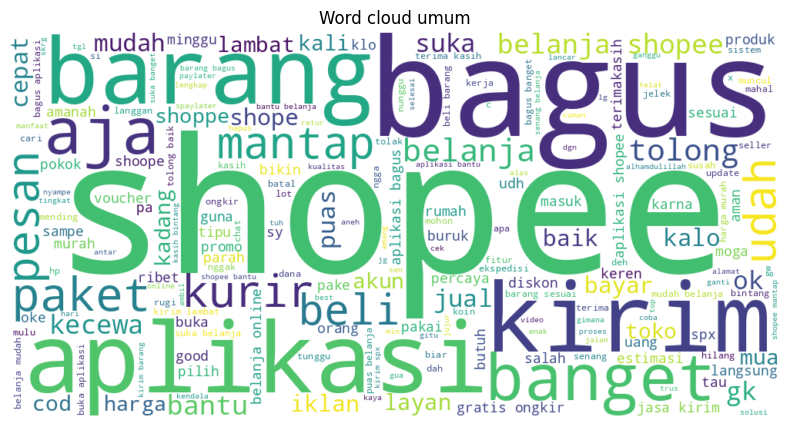

In [150]:
# world cloud umum
from wordcloud import WordCloud

text_all = ' '.join(clean_df['clean_text'].values)
wc_all = WordCloud(width=1000, height=500, background_color='white').generate(text_all)

plt.figure(figsize=(10, 5))
plt.imshow(wc_all, interpolation='bilinear')
plt.title('Word cloud umum')
plt.axis('off')
plt.show()

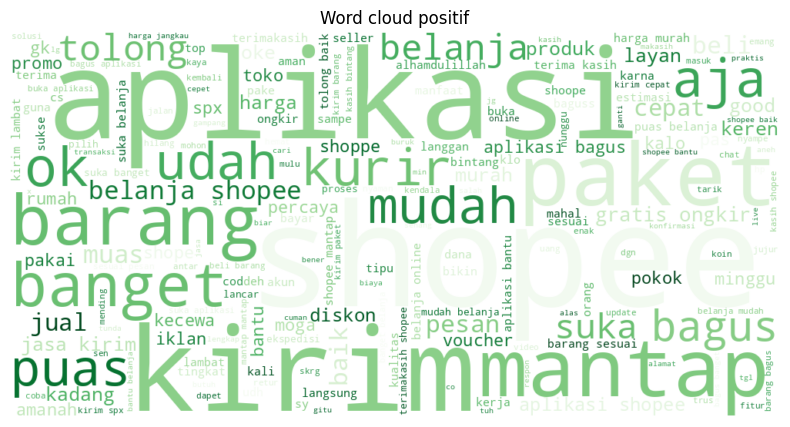

In [151]:
# word cloud positif
text_pos = ' '.join(clean_df[clean_df['polarity'] == 'positif']['clean_text'].values)
wc_pos = WordCloud(width=1000, height=500, background_color='white', colormap='Greens').generate(text_pos)

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.title('Word cloud positif')
plt.axis('off')
plt.show()

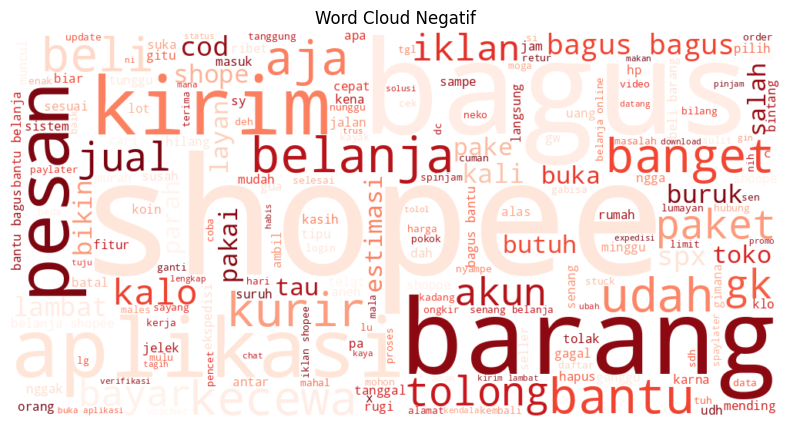

In [152]:
# word cloud negatif
text_neg = ' '.join(clean_df[clean_df['polarity'] == 'negatif']['clean_text'].values)
wc_neg = WordCloud(width=1000, height=500, background_color='white', colormap='Reds').generate(text_neg)

plt.figure(figsize=(10, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.title('Word Cloud Negatif')
plt.axis('off')
plt.show()

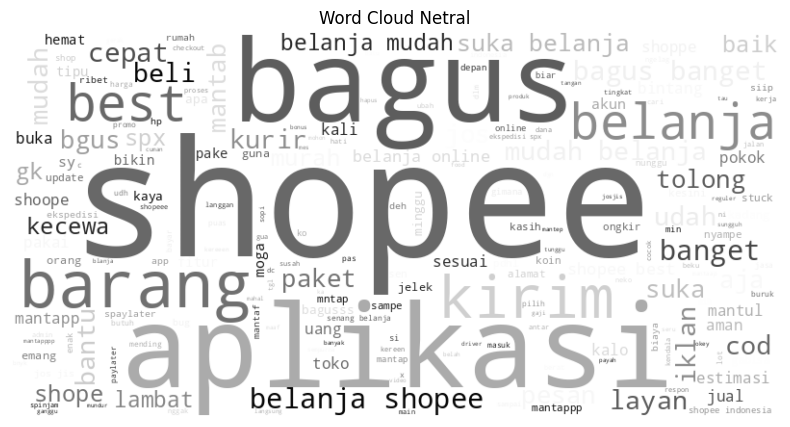

In [153]:
# word cloud netral
text_net = ' '.join(clean_df[clean_df['polarity'] == 'netral']['clean_text'].values)
wc_net = WordCloud(width=800, height=400, background_color='white', colormap='Greys').generate(text_net)

plt.figure(figsize=(10, 5))
plt.imshow(wc_net, interpolation='bilinear')
plt.title('Word Cloud Netral')
plt.axis('off')
plt.show()

**Balancing data**

In [154]:
# Tujuan : menyeimbangkan jumlah data tiap kelas, agar model tidak bias ke kelas yang dominan
# kalau tidak dibalance, model akan lebih mudah mengenali positif tapi sulit mengenali netral karena datanya sedikit

df_pos = clean_df[clean_df['polarity'] == 'positif']
df_neg = clean_df[clean_df['polarity'] == 'negatif']
df_net = clean_df[clean_df['polarity'] == 'netral']

print(f"Sebelum balancing:")
print(f"Positif : {len(df_pos)}")
print(f"Negatif : {len(df_neg)}")
print(f"Netral  : {len(df_net)}")

# samakan ke kelas terkecil (minimal 1000)
min_size = max(1000, min(len(df_pos), len(df_neg), len(df_net)))

df_pos_bal = resample(df_pos, n_samples=min_size, random_state=42)
df_neg_bal = resample(df_neg, n_samples=min_size, random_state=42)
df_net_bal = resample(df_net, n_samples=min_size, random_state=42)

# menggabungkan dan mengacak urutan data
clean_df = pd.concat([df_pos_bal, df_neg_bal, df_net_bal])
clean_df = clean_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nSetelah balancing:")
print(clean_df['polarity'].value_counts())
print(f"Total data: {len(clean_df)}")

Sebelum balancing:
Positif : 6262
Negatif : 3774
Netral  : 1612

Setelah balancing:
polarity
positif    1612
negatif    1612
netral     1612
Name: count, dtype: int64
Total data: 4836


**Data Splitting**

In [155]:
X = clean_df['clean_text'].values # fitur
y = clean_df['polarity'].values # label (positif/negatif/netral)

# split data 80/20 untuk skema pelatihan 1 dan 2
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# split data 70/30 untuk skema pelatihan 3
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"split 80/20 = train: {len(X_train_80)}, test: {len(X_test_80)}")
print(f"split 70/30 = train: {len(X_train_70)}, test: {len(X_test_70)}")

split 80/20 = train: 3868, test: 968
split 70/30 = train: 3385, test: 1451


**Skema 1: SVM + TF-IDF**

In [156]:
# SVM    : mencari batas pemisah optimal antar kelas
# TF-IDF : mengubah teks menjadi vektor angka berdasarkan seberapa penting suatu kata dalam dokumen

# ekstraksi fitur TF-IDF
# max_features : mengambil 20.000 kata paling penting
# ngram_range  : (1,2) = unigram dan bigram
tfidf_skema1   = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf1 = tfidf_skema1.fit_transform(X_train_80)
X_test_tfidf1  = tfidf_skema1.transform(X_test_80)

# pelatihan model SVM
# kernel='linear'
model_svm = SVC(kernel='linear', C=1.0, random_state=42)
model_svm.fit(X_train_tfidf1, y_train_80)

# evaluasi
y_pred_svm    = model_svm.predict(X_test_tfidf1)
acc_train_svm = model_svm.score(X_train_tfidf1, y_train_80)
acc_test_svm  = accuracy_score(y_test_80, y_pred_svm)

print("SKEMA 1: SVM + TF-IDF dengan data splitting 80/20")
print()
print(f"Train Accuracy : {acc_train_svm:.4f} ({acc_train_svm*100:.2f}%)")
print(f"Test Accuracy  : {acc_test_svm:.4f} ({acc_test_svm*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test_80, y_pred_svm))

SKEMA 1: SVM + TF-IDF dengan data splitting 80/20

Train Accuracy : 0.9925 (99.25%)
Test Accuracy  : 0.8926 (89.26%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.90      0.88       322
      netral       0.91      0.88      0.89       323
     positif       0.91      0.89      0.90       323

    accuracy                           0.89       968
   macro avg       0.89      0.89      0.89       968
weighted avg       0.89      0.89      0.89       968



**Skema 2: RandomForest + TF-IDF**

In [157]:
# RandomForest       : menggabungkan banyak decision tree
# TF-IDF : mengubah teks menjadi vektor angka berdasarkan seberapa penting suatu kata dalam dokumen

# ekstraksi fitur TF-IDF
tfidf_skema2   = TfidfVectorizer(max_features=15000, ngram_range=(1, 3))
X_train_tfidf2 = tfidf_skema2.fit_transform(X_train_80)
X_test_tfidf2  = tfidf_skema2.transform(X_test_80)

# pelatihan model RandomForest
model_rf_w2v = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_rf_w2v.fit(X_train_tfidf2, y_train_80)

# evaluasi
y_pred_rf_w2v    = model_rf_w2v.predict(X_test_tfidf2)
acc_train_rf_w2v = model_rf_w2v.score(X_train_tfidf2, y_train_80)
acc_test_rf_w2v  = accuracy_score(y_test_80, y_pred_rf_w2v)

print("SKEMA 2: RandomForest + TF-IDF dengan data splitting 80/20")
print()
print(f"Train Accuracy : {acc_train_rf_w2v:.4f} ({acc_train_rf_w2v*100:.2f}%)")
print(f"Test Accuracy  : {acc_test_rf_w2v:.4f} ({acc_test_rf_w2v*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test_80, y_pred_rf_w2v))

SKEMA 2: RandomForest + TF-IDF dengan data splitting 80/20

Train Accuracy : 0.9984 (99.84%)
Test Accuracy  : 0.8853 (88.53%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.90      0.88      0.89       322
      netral       0.89      0.92      0.90       323
     positif       0.87      0.86      0.87       323

    accuracy                           0.89       968
   macro avg       0.89      0.89      0.89       968
weighted avg       0.89      0.89      0.89       968



**Skema 3: Logistic Regression + TF-IDF**

In [158]:
# Logistic regression : algoritma klasifikasi yg menghitung probabilitas dimana suatu data masuk ke suatu kelas tertentu

from sklearn.linear_model import LogisticRegression

# ekstraksi fitur TF-IDF
tfidf_skema3   = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf3 = tfidf_skema3.fit_transform(X_train_70)
X_test_tfidf3  = tfidf_skema3.transform(X_test_70)

# pelatihan model Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_tfidf3, y_train_70)

# evaluasi
y_pred_lr    = model_lr.predict(X_test_tfidf3)
acc_train_lr = model_lr.score(X_train_tfidf3, y_train_70)
acc_test_lr  = accuracy_score(y_test_70, y_pred_lr)

print("SKEMA 3: Logistic Regression + TF-IDF dengan data splitting 70/30")
print()
print(f"Train Accuracy : {acc_train_lr:.4f} ({acc_train_lr*100:.2f}%)")
print(f"Test Accuracy  : {acc_test_lr:.4f} ({acc_test_lr*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test_70, y_pred_lr))

SKEMA 3: Logistic Regression + TF-IDF dengan data splitting 70/30

Train Accuracy : 0.9796 (97.96%)
Test Accuracy  : 0.8567 (85.67%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.85      0.85      0.85       483
      netral       0.85      0.87      0.86       484
     positif       0.87      0.85      0.86       484

    accuracy                           0.86      1451
   macro avg       0.86      0.86      0.86      1451
weighted avg       0.86      0.86      0.86      1451



**Evaluasi Model: Dengan 3 Skema(algoritma) dan 2 Kombinasi(ekstraksi fitur/pembagian data)**</br>
* *Kombinasi 1: Algoritma yang digunakan berbeda (SVM, RandomForest, Logistic Regression)*
* *Kombinasi 2: Data splitting yang digunakan berbeda (80/20, 70/30)*

In [159]:
# tabel perbandingan dataframe
results_df = pd.DataFrame({
    'Model': ['SVM', 'RandomForest', 'Logistic Regression'],
    'Accuracy Train': [acc_train_svm, acc_train_rf_w2v, acc_train_lr],
    'Accuracy Test': [acc_test_svm, acc_test_rf_w2v, acc_test_lr]})
results_df

,Model,Accuracy Train,Accuracy Test
0,SVM,0.992503,0.892562
1,RandomForest,0.998449,0.885331
2,Logistic Regression,0.979616,0.856651


In [160]:
# perbandingan evaluasi + clasification report
print("\nAkurasi SVM - Training: {:.2f}%".format(acc_train_svm * 100))
print("Akurasi SVM - Testing : {:.2f}%".format(acc_test_svm * 100))

print("\nAkurasi RandomForest - Training: {:.2f}%".format(acc_train_rf_w2v * 100))
print("Akurasi RandomForest - Testing : {:.2f}%".format(acc_test_rf_w2v * 100))

print("\nAkurasi Logistic Regression - Training: {:.2f}%".format(acc_train_lr * 100))
print("Akurasi Logistic Regression - Testing : {:.2f}%".format(acc_test_lr * 100))

print("\nClassification Report - SVM:")
print(classification_report(y_test_80, y_pred_svm))

print("\nClassification Report - Random Forest:")
print(classification_report(y_test_80, y_pred_rf_w2v))

print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test_70, y_pred_lr))


Akurasi SVM - Training: 99.25%
Akurasi SVM - Testing : 89.26%

Akurasi RandomForest - Training: 99.84%
Akurasi RandomForest - Testing : 88.53%

Akurasi Logistic Regression - Training: 97.96%
Akurasi Logistic Regression - Testing : 85.67%

Classification Report - SVM:
              precision    recall  f1-score   support

     negatif       0.86      0.90      0.88       322
      netral       0.91      0.88      0.89       323
     positif       0.91      0.89      0.90       323

    accuracy                           0.89       968
   macro avg       0.89      0.89      0.89       968
weighted avg       0.89      0.89      0.89       968


Classification Report - Random Forest:
              precision    recall  f1-score   support

     negatif       0.90      0.88      0.89       322
      netral       0.89      0.92      0.90       323
     positif       0.87      0.86      0.87       323

    accuracy                           0.89       968
   macro avg       0.89      0.89     

In [161]:
# tabel perbandingan
print(f"{'Skema':<10} {'Algoritma':<22} {'Fitur':<12} {'Split':<8} {'Train Acc':>10} {'Test Acc':>10}")
print()
print(f"{'Skema 1':<10} {'SVM':<22} {'TF-IDF':<12} {'80/20':<8} {acc_train_svm:>10.4f} {acc_test_svm:>10.4f}")
print(f"{'Skema 2':<10} {'Random Forest':<22} {'TF-IDF':<12} {'80/20':<8} {acc_train_rf_w2v:>10.4f} {acc_test_rf_w2v:>10.4f}")
print(f"{'Skema 3':<10} {'Logistic Regression':<22} {'TF-IDF':<12} {'70/30':<8} {acc_train_lr:>10.4f} {acc_test_lr:>10.4f}")
print()

skema_label = [
    'Skema 1\nSVM+TFIDF\n80/20',
    'Skema 2\nRF+TFIDF\n80/20',
    'Skema 3\nLR+TFIDF\n70/30']

Skema      Algoritma              Fitur        Split     Train Acc   Test Acc

Skema 1    SVM                    TF-IDF       80/20        0.9925     0.8926
Skema 2    Random Forest          TF-IDF       80/20        0.9984     0.8853
Skema 3    Logistic Regression    TF-IDF       70/30        0.9796     0.8567



**Inference**

In [162]:
# fungsi preprocessing untuk interface
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword.remove(text)
    text = stemmer.stem(text)
    return text

# karena model svm memiliki akurasi test yang tinggi, maka akan menggunakan model tersebut
def predict_sentiment(text):
    # preprocessing teks input
    clean = preprocess(text)

    # ekstraksi fitur menggunakan vectorizer skema 1
    vector = tfidf_skema1.transform([clean])

    # prediksi sentimen
    prediction = model_svm.predict(vector)

    return prediction[0]

# testing inference dengan beberapa contoh kalimat
test_kalimat = [
    "bagus banget aplikasinya, puas belanja disini",
    "jelek banget, buruk, tidak suka",
    "biasa saja"]

print("hasil inference")
for kalimat in test_kalimat:
    hasil = predict_sentiment(kalimat)
    print(f"\nInput  : {kalimat}")
    print(f"Output : {hasil.upper()}")

hasil inference

Input  : bagus banget aplikasinya, puas belanja disini
Output : POSITIF

Input  : jelek banget, buruk, tidak suka
Output : NEGATIF

Input  : biasa saja
Output : NETRAL


**Requirements.txt**

In [163]:
%%writefile requirements.txt
google-play-scraper==1.2.7
pandas
numpy
matplotlib
scikit-learn
PySastrawi
nltk
gensim
wordcloud
seaborn
string
re
pickle
collections

Overwriting requirements.txt
